# Synchrony — ABC Bank 신용카드 이용·해지 EDA

**목표:** ABC 카드(`Payment_Code = 3`)의 사용 감소·미사용과 이후 해지 기록의 관계를 탐색합니다.
[01 원본 로드·기본 정제](01_data_load_clean.ipynb)의 데이터 사전과 결측치 해석을 사용합니다.

| 구분 | 이 노트북의 기준 |
| --- | --- |
| 중심 고객 | 발급일이 확인되고 분석 기간에 ABC 카드를 보유한 고객. ABC 구매가 0건인 고객도 포함 |
| 중심 거래 | ABC 카드의 구매·반품 기록 |
| 해지 정보 | 고객 테이블의 ABC 카드 발급일·해지일. 다른 은행 카드의 해지는 알 수 없음 |
| 타 결제수단 | **동일한 ABC 보유 고객·동일 기간**의 사용 비중과 결제 이동 징후를 확인하는 보조 정보 |
| 관측 범위 | 제공된 제휴몰 기록. 다른 가맹점을 포함한 카드 전체 사용량은 알 수 없음 |

제공 기록에 수집 누락이 없다는 전제로 거래 부재를 0으로 집계합니다. 따라서 ‘미사용’은 **이 제휴몰에서 구매 기록이 없음**을 뜻합니다.
원본 결측은 유지하고, 거래 집계가 없는 고객의 건수·금액만 0으로 채웁니다.
이 노트북은 기술 통계와 해지 전 행동 탐색이며, 해지의 원인이나 모델 성능을 검증하지 않습니다.

## 1. 독립적인 원본 로드와 ABC 거래 확인

01을 먼저 실행하지 않아도 됩니다. 같은 `read_source`로 원본을 로드하고, 코드표에서 ABC 카드를 확인합니다.
ABC 거래가 발급 전·해지 후에 나타나는지 검사한 뒤 고객의 카드 보유 기간에 해당하는 기록을 구성합니다. 해지 당일 거래는 허용합니다.

In [1]:
from pathlib import Path
import os
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src/experiments/synchrony/data.py").is_file()
     and (path / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Cardops 저장소 안에서 노트북을 실행해 주세요.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
SOURCE_ZIP = Path(os.environ.get(
    "SYNCHRONY_SOURCE_ZIP", PROJECT_ROOT / "data/raw/Synchrony/Datasets.zip"
)).expanduser()
if not SOURCE_ZIP.is_file():
    raise FileNotFoundError(f"원본 ZIP을 준비해 주세요: {SOURCE_ZIP}")

font_names = {font.name for font in font_manager.fontManager.ttflist}
plot_font = next((name for name in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]
                  if name in font_names), "DejaVu Sans")
sns.set_theme(style="whitegrid", rc={"font.family": plot_font, "axes.unicode_minus": False})
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 12})
pd.set_option("display.max_columns", 20)
print("원본:", SOURCE_ZIP)
print("그래프 글꼴:", plot_font)

원본: /Users/geonwookim/Desktop/skn34_project/Cardops/data/raw/Synchrony/Datasets.zip
그래프 글꼴: AppleGothic


In [2]:
from src.experiments.synchrony.data import read_source

customers, transactions = read_source(SOURCE_ZIP)
with zipfile.ZipFile(SOURCE_ZIP) as archive:
    payment_codes = pd.read_csv(archive.open("Datasets/Payment Code.csv"))
    category_codes = pd.read_csv(archive.open("Datasets/Category Code.csv"))

CARD_PAYMENT_CODE = 3
assert payment_codes["Payment_Code"].is_unique
assert category_codes["Category_Code"].is_unique
assert transactions["Payment_Code"].isin(payment_codes["Payment_Code"]).all()
assert transactions["Category_Code"].isin(category_codes["Category_Code"]).all()
assert transactions["Transaction_Type"].isin(["Sale", "Return"]).all()
assert payment_codes.set_index("Payment_Code").loc[CARD_PAYMENT_CODE, "Payment_Method"] == "ABC Bank Credit Card"
observation_start = transactions["Transaction_Date"].min()
observation_end = transactions["Transaction_Date"].max()
all_months = pd.period_range(observation_start, observation_end, freq="M")
opened = customers["Credit_Card_Open_Date"]
closed = customers["Credit_Card_Closed_Date"]
assert (closed.isna() | (opened.notna() & closed.ge(opened))).all()

linked = transactions.join(customers[["Credit_Card_Open_Date", "Credit_Card_Closed_Date"]], on="Customer_ID")
within_holding = (
    linked["Transaction_Date"].ge(linked["Credit_Card_Open_Date"])
    & (linked["Credit_Card_Closed_Date"].isna()
       | linked["Transaction_Date"].le(linked["Credit_Card_Closed_Date"]))
)
is_abc = linked["Payment_Code"].eq(CARD_PAYMENT_CODE)
assert within_holding.loc[is_abc].all(), "ABC 거래 중 발급 전·해지 후 또는 발급 정보 미기록 거래 확인 필요"
abc_transactions = transactions.loc[is_abc].copy()
abc_sales = abc_transactions.loc[abc_transactions["Transaction_Type"].eq("Sale")].copy()
abc_returns = abc_transactions.loc[abc_transactions["Transaction_Type"].eq("Return")].copy()
# 타 결제수단 보조 분석도 ABC 카드를 보유했던 날짜의 기록만 사용합니다.
owned_sales = linked.loc[within_holding & linked["Transaction_Type"].eq("Sale"), transactions.columns].copy()
print(f"관측 기간: {observation_start.date()} ~ {observation_end.date()} ({len(all_months)}개월)")
display(payment_codes.loc[payment_codes["Payment_Code"].eq(CARD_PAYMENT_CODE)])
print(f"ABC 구매 {len(abc_sales):,}행 / ABC 반품 {len(abc_returns):,}행")

관측 기간: 2024-08-01 ~ 2026-07-31 (24개월)


,Payment_Code,Payment_Method
2,3,ABC Bank Credit Card


ABC 구매 71,778행 / ABC 반품 7,736행


## 2. ABC 분석 대상 고객과 카드 특성

분석 대상은 **관측 기간과 ABC 카드 보유 기간이 하루 이상 겹치는 고객**입니다.
발급일 미기록, 관측 시작 전 해지, 관측 종료 후 발급 고객은 이유를 표시해 이 분석에서 제외합니다.
이는 원본 삭제가 아니며, 발급일 미기록을 확정적인 미발급으로 해석하지 않습니다.

종료일까지 미해지에는 종료일 이후 해지일이 기록된 고객도 포함됩니다. 미래 기록을 현재 상태에 섞지 않습니다.
아래 고객 특성은 ABC 대상 고객만 요약합니다. 나이·성별·멤버십·한도·APR은 제공된 고객 테이블의 값으로,
과거 시점의 값이 보장되지 않아 뒤의 해지 전 행동 비교에는 입력하지 않습니다. 금액 및 APR의 표시 단위는 CSV에 명시되어 있지 않습니다.

,고객 수,전체 고객 대비 비율(%),ABC EDA 포함
분류,,,
발급일 미기록,6836,15.19,False
관측 종료 후 발급,126,0.28,False
관측 시작 전 해지,1704,3.79,False
관측 중 해지,5815,12.92,True
종료일까지 미해지,30519,67.82,True


ABC EDA 고객 수             36334
관측 기간 중 ABC 구매 기록 있음     26619
관측된 보유 기간 중 ABC 구매 0건     9715
관측 종료일 현재 미해지            30519
Name: 고객 수, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Age,36334.0,38.62,11.32,18.0,30.00,38.00,47.00,60.0
Credit_Card_Limit,36334.0,199932.74,57638.62,100000.0,150000.00,200000.00,250000.00,300000.0
Credit_Card_APR,36334.0,31.50,2.02,28.0,29.76,31.51,33.26,35.0
observed_days,36334.0,531.99,248.00,1.0,322.00,727.00,730.00,730.0


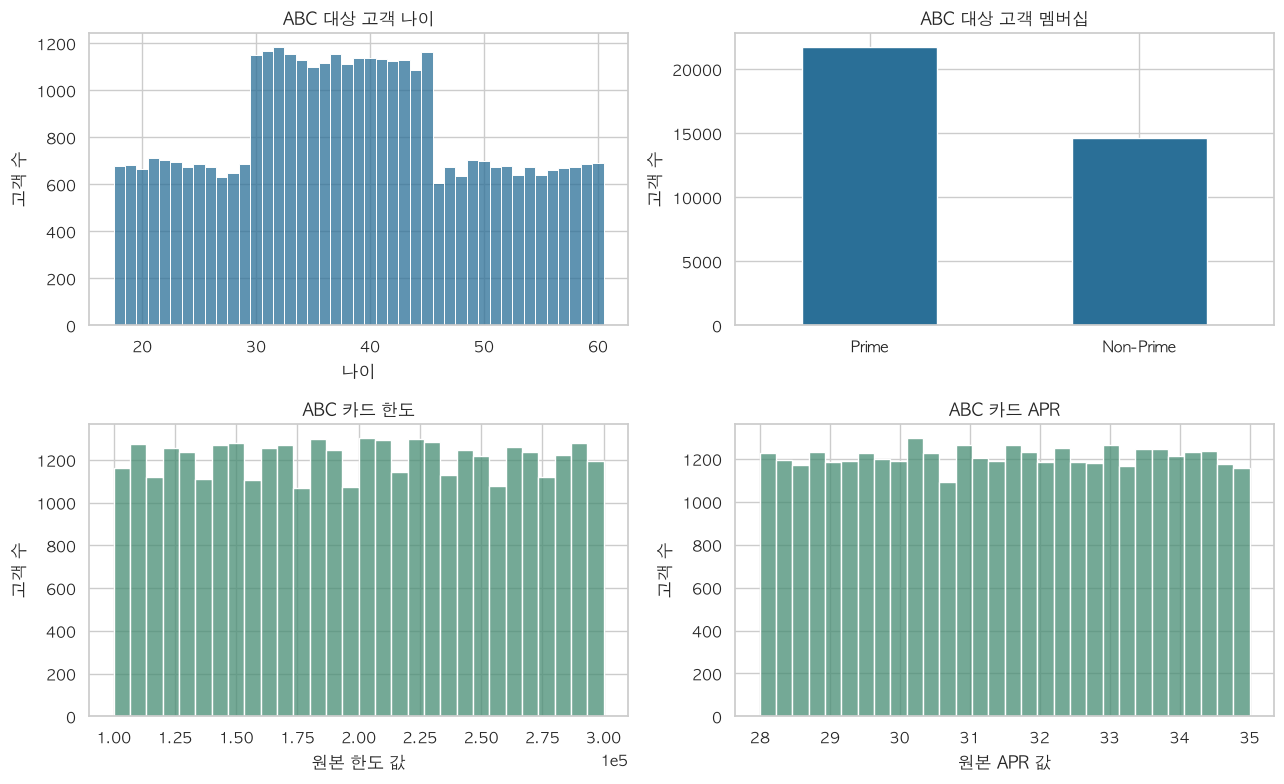

In [3]:
cohort_labels = ["발급일 미기록", "관측 종료 후 발급", "관측 시작 전 해지", "관측 중 해지", "종료일까지 미해지"]
scope = pd.Series(np.select(
    [opened.isna(), opened.gt(observation_end), closed.lt(observation_start), closed.le(observation_end)],
    cohort_labels[:4], default=cohort_labels[4],
), index=customers.index, name="분류")
scope_summary = scope.value_counts().reindex(cohort_labels, fill_value=0).to_frame("고객 수")
scope_summary["전체 고객 대비 비율(%)"] = scope_summary["고객 수"].div(len(customers)).mul(100)
scope_summary["ABC EDA 포함"] = scope_summary.index.isin(cohort_labels[3:])
assert scope_summary["고객 수"].sum() == len(customers)
display(scope_summary.round(2))

abc_customers = customers.loc[scope.isin(cohort_labels[3:])].copy()
abc_customers["end_status"] = scope.reindex(abc_customers.index)
usage = abc_sales.groupby("Customer_ID").agg(
    abc_count=("Number_of_Transactions", "sum"), abc_amount=("Transaction_Amount", "sum"),
)
abc_customers = abc_customers.join(usage)
abc_customers[["abc_count", "abc_amount"]] = abc_customers[["abc_count", "abc_amount"]].fillna(0)
abc_customers["observed_days"] = (
    abc_customers["Credit_Card_Closed_Date"].fillna(observation_end).clip(upper=observation_end)
    - abc_customers["Credit_Card_Open_Date"].clip(lower=observation_start)
).dt.days.add(1)
assert abc_customers["observed_days"].gt(0).all()
assert abc_sales["Customer_ID"].isin(abc_customers.index).all()
assert np.isclose(abc_customers["abc_amount"].sum(), abc_sales["Transaction_Amount"].sum())
display(pd.Series({
    "ABC EDA 고객 수": len(abc_customers),
    "관측 기간 중 ABC 구매 기록 있음": abc_customers["abc_count"].gt(0).sum(),
    "관측된 보유 기간 중 ABC 구매 0건": abc_customers["abc_count"].eq(0).sum(),
    "관측 종료일 현재 미해지": abc_customers["end_status"].eq(cohort_labels[4]).sum(),
}, name="고객 수"))
display(abc_customers[["Age", "Credit_Card_Limit", "Credit_Card_APR", "observed_days"]].describe().T.round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(data=abc_customers, x="Age", discrete=True, ax=axes[0, 0], color="#2a6f97")
axes[0, 0].set(title="ABC 대상 고객 나이", xlabel="나이", ylabel="고객 수")
abc_customers["Membership_Type"].value_counts().plot.bar(ax=axes[0, 1], rot=0, color="#2a6f97")
axes[0, 1].set(title="ABC 대상 고객 멤버십", xlabel="", ylabel="고객 수")
sns.histplot(data=abc_customers, x="Credit_Card_Limit", bins=30, ax=axes[1, 0], color="#468c73")
axes[1, 0].set(title="ABC 카드 한도", xlabel="원본 한도 값", ylabel="고객 수")
axes[1, 0].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
sns.histplot(data=abc_customers, x="Credit_Card_APR", bins=30, ax=axes[1, 1], color="#468c73")
axes[1, 1].set(title="ABC 카드 APR", xlabel="원본 APR 값", ylabel="고객 수")
fig.tight_layout()
plt.show()

## 3. ABC 카드 구매·반품 규모와 분포

이 절의 모든 거래는 **ABC 카드 결제만** 포함합니다.
구매 건수는 `Number_of_Transactions`의 합계이며 기록 행 수와 다릅니다.
반품 건수 결측은 유지하고, 반품 금액과 기록 행 수를 별도로 봅니다. 반품 금액도 양수입니다.
구매·반품 연결 키가 없어 구매별 반품률로 해석하지 않습니다. 금액 그래프만 `log1p`를 적용합니다.

,고객수,기록행수,기록금액,거래건수
Transaction_Type,,,,
Sale,26619,71778,2.396616e+08,819644.0
Return,6674,7736,2.558190e+07,NaN


,count,mean,std,min,1%,50%,95%,99%,max
Transaction_Type,,,,,,,,,
Return,7736.0,3306.86,2751.15,163.44,414.07,2202.06,9999.99,9999.99,9999.99
Sale,71778.0,3338.93,2779.06,132.93,416.73,2243.06,9999.99,9999.99,9999.99


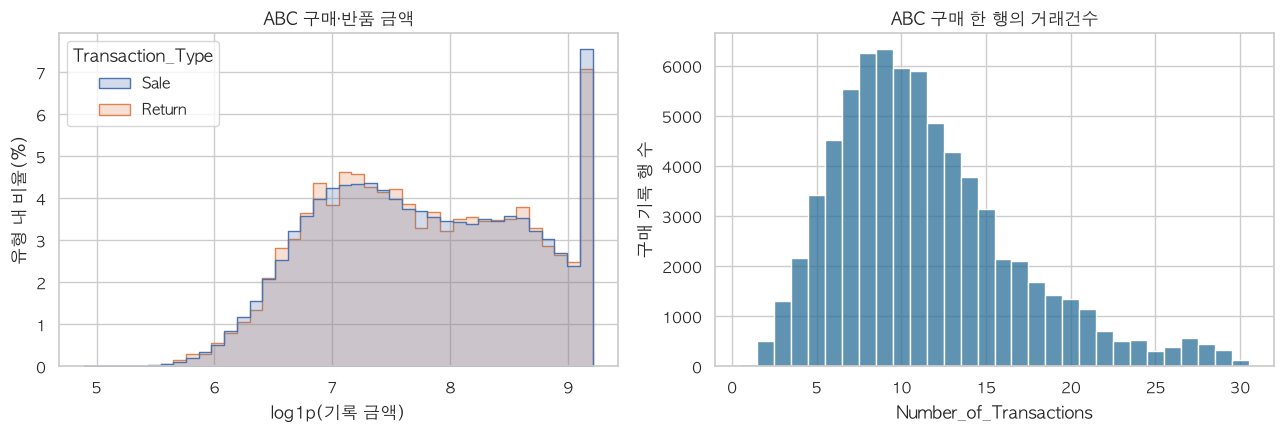

In [4]:
assert abc_sales["Number_of_Transactions"].notna().all()
assert abc_sales["Number_of_Transactions"].gt(0).all()
assert abc_sales["Number_of_Transactions"].mod(1).eq(0).all()
assert abc_transactions["Transaction_Amount"].ge(0).all()
type_summary = abc_transactions.groupby("Transaction_Type").agg(
    고객수=("Customer_ID", "nunique"), 기록행수=("Transaction_ID", "size"),
    기록금액=("Transaction_Amount", "sum"),
    거래건수=("Number_of_Transactions", lambda values: values.sum(min_count=1)),
).reindex(["Sale", "Return"])
display(type_summary.round(2))
display(abc_transactions.groupby("Transaction_Type")["Transaction_Amount"].describe(
    percentiles=[0.01, 0.5, 0.95, 0.99]
).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=abc_transactions.assign(log_amount=np.log1p(abc_transactions["Transaction_Amount"])),
             x="log_amount", hue="Transaction_Type", bins=40, stat="percent", common_norm=False,
             element="step", ax=axes[0])
axes[0].set(title="ABC 구매·반품 금액", xlabel="log1p(기록 금액)", ylabel="유형 내 비율(%)")
sns.histplot(data=abc_sales, x="Number_of_Transactions", discrete=True, ax=axes[1], color="#2a6f97")
axes[1].set(title="ABC 구매 한 행의 거래건수", xlabel="Number_of_Transactions", ylabel="구매 기록 행 수")
fig.tight_layout()
plt.show()

## 4. 월별 ABC 사용·발급·해지 추이

- **월중 보유 고객:** 해당 월과 관측 기간 안에서 ABC 카드를 하루 이상 보유한 고객. 구매 0건 고객도 포함합니다.
- **월중 구매 고객 비율:** ABC 구매 고객 수 ÷ 월중 보유 고객 수. 신규·해지 고객은 관측일 수가 짧을 수 있습니다.
- **월초 기존 보유 고객:** 월초 전날까지 발급되고 월초보다 먼저 해지하지 않은 고객.
- **월초 기존 고객의 월내 해지 비율:** 위 고객 중 해당 월에 해지한 고객 수 ÷ 위 고객 수.
  월중 신규 발급 고객은 이 해지 비율의 분모·분자에서 모두 제외합니다. 전체 월내 해지 건수도 별도로 표시합니다.

제공 자료는 월 단위 전체 기간이 있는지 검사합니다. 해지 당일은 거래 분석의 보유일에 포함하고,
월말 상태는 해지일이 월말보다 뒤이거나 해지일 미기록인 경우에만 미해지로 봅니다.

,ABC 구매 고객,ABC 구매 행 수,ABC 구매 건수,ABC 구매 금액,ABC 반품 금액,ABC 반품 행 수,월중 보유 고객,월초 기존 보유 고객,월말 미해지 고객,신규 발급,전체 월내 해지,월초 기존 고객 중 해지,월중 구매 고객 비율(%),월초 기존 고객 해지 비율(%),월중 ABC 구매 0건 고객
2024-08,3017,3291,37446.0,10916672.45,1141888.35,329,21514.0,20894.0,21395.0,620.0,119.0,118.0,14.02,0.56,18497.0
2024-09,2893,3167,35849.0,10612365.11,1156951.56,335,21998.0,21395.0,21876.0,603.0,122.0,119.0,13.15,0.56,19105.0
2024-10,3043,3319,38079.0,10831446.35,1319422.99,396,22546.0,21876.0,22431.0,670.0,115.0,112.0,13.50,0.51,19503.0
2024-11,3057,3296,37303.0,10923136.26,1201983.84,359,23046.0,22431.0,22929.0,615.0,117.0,116.0,13.26,0.52,19989.0
2024-12,3219,3509,39610.0,11665915.43,1316256.31,390,23580.0,22929.0,23438.0,651.0,142.0,136.0,13.65,0.59,20361.0
2025-01,3208,3493,39144.0,11878202.54,1279840.49,381,24104.0,23438.0,23954.0,666.0,150.0,147.0,13.31,0.63,20896.0
2025-02,3198,3437,39144.0,11825964.21,1235049.05,400,24591.0,23954.0,24451.0,637.0,140.0,139.0,13.00,0.58,21393.0
2025-03,3608,3926,45170.0,12860974.49,1252720.20,399,25078.0,24451.0,24911.0,627.0,167.0,164.0,14.39,0.67,21470.0
2025-04,3459,3796,43935.0,12826492.11,1341592.36,423,25614.0,24911.0,25419.0,703.0,195.0,188.0,13.50,0.75,22155.0
2025-05,3577,3902,44617.0,12688389.59,1451648.96,419,26048.0,25419.0,25881.0,629.0,167.0,164.0,13.73,0.65,22471.0


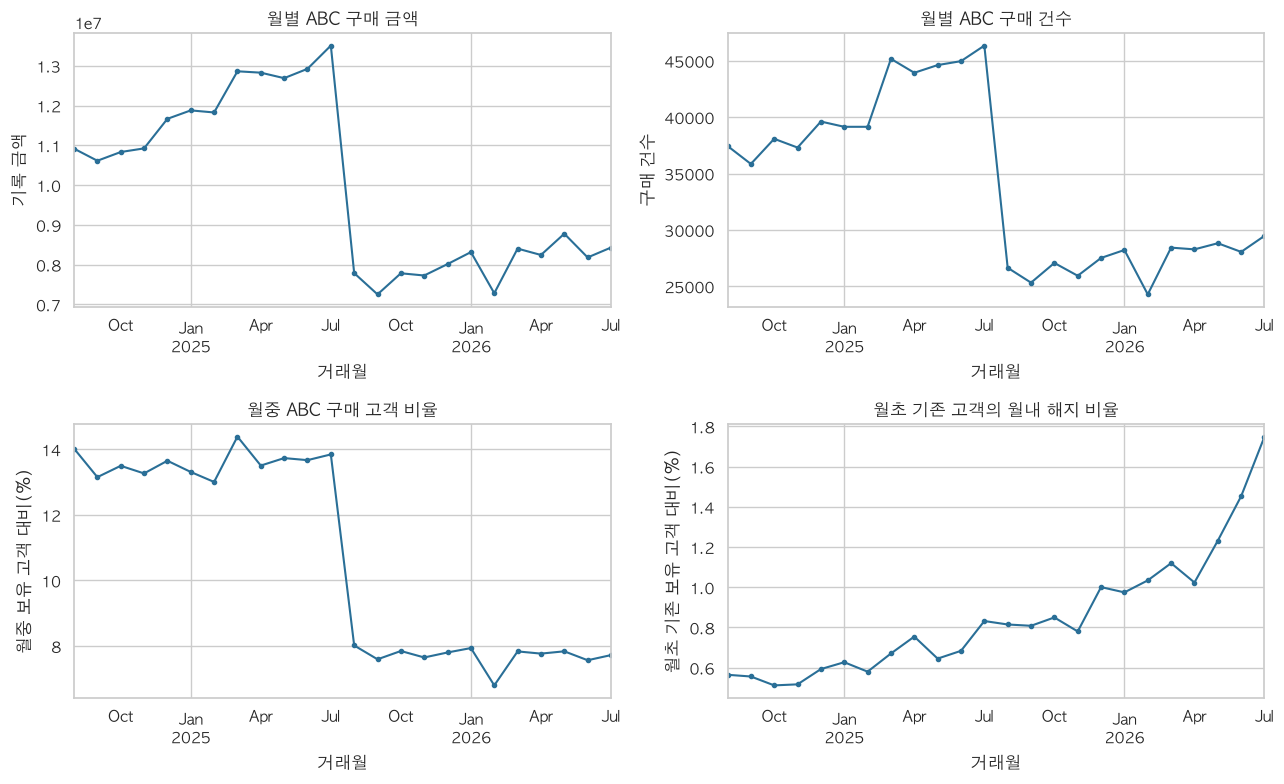

In [5]:
assert observation_start == all_months[0].start_time.normalize()
assert observation_end == all_months[-1].end_time.normalize()
monthly = abc_sales.groupby("month").agg(
    abc_buyers=("Customer_ID", "nunique"), abc_rows=("Transaction_ID", "size"),
    abc_count=("Number_of_Transactions", "sum"), abc_amount=("Transaction_Amount", "sum"),
).reindex(all_months, fill_value=0)
monthly["abc_return_amount"] = abc_returns.groupby("month")["Transaction_Amount"].sum().reindex(all_months, fill_value=0)
monthly["abc_return_rows"] = abc_returns.groupby("month").size().reindex(all_months, fill_value=0)
for month in all_months:
    start, end = month.start_time.normalize(), month.end_time.normalize()
    exposed = opened.le(end) & (closed.isna() | closed.ge(start))
    start_holders = opened.lt(start) & (closed.isna() | closed.ge(start))
    end_holders = opened.le(end) & (closed.isna() | closed.gt(end))
    month_closures = closed.between(start, end)
    monthly.loc[month, "holders_in_month"] = exposed.sum()
    monthly.loc[month, "holders_at_start"] = start_holders.sum()
    monthly.loc[month, "holders_at_end"] = end_holders.sum()
    monthly.loc[month, "new_cards"] = opened.between(start, end).sum()
    monthly.loc[month, "closed_cards"] = month_closures.sum()
    monthly.loc[month, "closed_from_start"] = (start_holders & month_closures).sum()
monthly["purchase_customer_pct"] = monthly["abc_buyers"].div(monthly["holders_in_month"].replace(0, np.nan)).mul(100)
monthly["start_holder_close_pct"] = monthly["closed_from_start"].div(monthly["holders_at_start"].replace(0, np.nan)).mul(100)
monthly["zero_purchase_customers"] = monthly["holders_in_month"] - monthly["abc_buyers"]
assert monthly["abc_buyers"].le(monthly["holders_in_month"]).all()
assert monthly["closed_from_start"].le(monthly["holders_at_start"]).all()
assert monthly["abc_count"].sum() == abc_sales["Number_of_Transactions"].sum()
assert np.isclose(monthly["abc_amount"].sum(), abc_sales["Transaction_Amount"].sum())
assert monthly["closed_cards"].sum() == closed.between(observation_start, observation_end).sum()
monthly_names = {
    "abc_buyers": "ABC 구매 고객", "abc_rows": "ABC 구매 행 수", "abc_count": "ABC 구매 건수",
    "abc_amount": "ABC 구매 금액", "abc_return_amount": "ABC 반품 금액", "abc_return_rows": "ABC 반품 행 수",
    "holders_in_month": "월중 보유 고객", "holders_at_start": "월초 기존 보유 고객", "holders_at_end": "월말 미해지 고객",
    "new_cards": "신규 발급", "closed_cards": "전체 월내 해지", "closed_from_start": "월초 기존 고객 중 해지",
    "purchase_customer_pct": "월중 구매 고객 비율(%)", "start_holder_close_pct": "월초 기존 고객 해지 비율(%)",
    "zero_purchase_customers": "월중 ABC 구매 0건 고객",
}
display(monthly.rename(columns=monthly_names).round(2))
plot_monthly = monthly.copy()
plot_monthly.index = plot_monthly.index.to_timestamp()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, column, title, ylabel in [
    (axes[0, 0], "abc_amount", "월별 ABC 구매 금액", "기록 금액"),
    (axes[0, 1], "abc_count", "월별 ABC 구매 건수", "구매 건수"),
    (axes[1, 0], "purchase_customer_pct", "월중 ABC 구매 고객 비율", "월중 보유 고객 대비(%)"),
    (axes[1, 1], "start_holder_close_pct", "월초 기존 고객의 월내 해지 비율", "월초 기존 보유 고객 대비(%)"),
]:
    plot_monthly[column].plot(ax=ax, marker="o", markersize=3, color="#2a6f97")
    ax.set(title=title, xlabel="거래월", ylabel=ylabel)
fig.tight_layout()
plt.show()

## 5. ABC 카드가 사용되는 상품 범주

**분모는 ABC 카드 구매 금액·건수 합계**입니다. 전체 쇼핑몰의 인기 범주와 구분합니다.
상품 범주 이름은 원본 표기를 유지하며, 여러 범주를 사용하는 고객은 중복 집계됩니다.

,ABC 구매 고객,ABC 구매 건수,ABC 구매 금액,상품 범주,ABC 금액 구성비(%),ABC 건수 구성비(%)
Category_Code,,,,,,
2,8712,122477.0,53093973.41,Electronics,22.15,14.94
7,4584,58363.0,41640695.87,Large Applicances,17.37,7.12
5,5294,67684.0,38507756.47,Furniture,16.07,8.26
9,4655,58803.0,31142148.75,Travel,12.99,7.17
3,7278,97972.0,18145604.77,Apparel,7.57,11.95
8,4459,56156.0,16371078.69,Outdoor,6.83,6.85
1,10191,149058.0,12942045.91,Grocery,5.40,18.19
6,5745,72665.0,11955898.35,Kids And Toys,4.99,8.87
4,6211,80893.0,10322817.31,Beauty,4.31,9.87


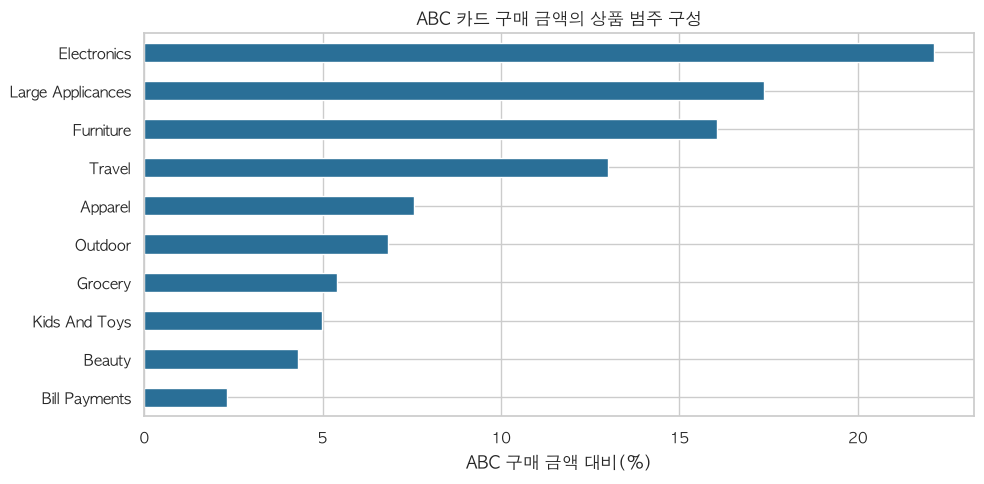

In [6]:
category_summary = abc_sales.groupby("Category_Code").agg(
    customers=("Customer_ID", "nunique"), count=("Number_of_Transactions", "sum"),
    amount=("Transaction_Amount", "sum"),
).reindex(category_codes["Category_Code"], fill_value=0).join(category_codes.set_index("Category_Code"))
category_summary["amount_share_pct"] = category_summary["amount"].div(category_summary["amount"].sum()).mul(100)
category_summary["count_share_pct"] = category_summary["count"].div(category_summary["count"].sum()).mul(100)
assert np.isclose(category_summary["amount"].sum(), abc_sales["Transaction_Amount"].sum())
display(category_summary.rename(columns={
    "Category": "상품 범주", "customers": "ABC 구매 고객", "count": "ABC 구매 건수",
    "amount": "ABC 구매 금액", "amount_share_pct": "ABC 금액 구성비(%)", "count_share_pct": "ABC 건수 구성비(%)",
}).sort_values("ABC 구매 금액", ascending=False).round(2))
fig, ax = plt.subplots(figsize=(10, 5))
category_summary.sort_values("amount").set_index("Category")["amount_share_pct"].plot.barh(ax=ax, color="#2a6f97")
ax.set(title="ABC 카드 구매 금액의 상품 범주 구성", xlabel="ABC 구매 금액 대비(%)", ylabel="")
fig.tight_layout()
plt.show()

## 6. 현재 ABC 보유 고객의 최근 구매·미사용·사용 감소

기준일에 **발급되어 있고 아직 해지되지 않은 고객 전체**를 먼저 선택한 뒤 구매 내역을 연결합니다.
ABC 구매 기록이 없는 보유 고객을 빠뜨리지 않습니다.

- 최근 90일: `(기준일 - 90일, 기준일]`, 직전 90일: `(기준일 - 180일, 기준일 - 90일]`.
- 90일간 구매 0건과 ‘관측된 과거 전체에 ABC 구매 기록 없음’을 구분합니다.
- 최근성은 마지막 **관측된 ABC 구매** 이후 경과일입니다. 관측된 구매가 없으면 결측을 유지합니다.
- 신규 발급 고객은 90일 전체를 관측하지 못할 수 있어 별도 표시합니다.
- 구매 감소 비교는 **180일 전체를 관측할 수 있는 보유 고객**에게만 적용합니다.

건수·금액은 제공된 제휴몰의 구매 기준입니다. 사용 감소나 0건을 해지로 판정하지 않습니다.

In [7]:
WINDOW_DAYS = 90

def abc_behavior_as_of(as_of):
    as_of = pd.Timestamp(as_of)
    eligible = opened.le(as_of) & (closed.isna() | closed.gt(as_of))
    frame = pd.DataFrame(index=customers.index[eligible])
    start_observed = opened.reindex(frame.index).clip(lower=observation_start)
    frame["observed_days"] = (as_of - start_observed).dt.days.add(1)
    frame["full_90_days"] = frame["observed_days"].ge(WINDOW_DAYS)
    frame["full_180_days"] = frame["observed_days"].ge(2 * WINDOW_DAYS)
    past = owned_sales.loc[owned_sales["Customer_ID"].isin(frame.index)
                           & owned_sales["Transaction_Date"].le(as_of)]
    past_abc = past.loc[past["Payment_Code"].eq(CARD_PAYMENT_CODE)]
    last_purchase = past_abc.groupby("Customer_ID")["Transaction_Date"].max().reindex(frame.index)
    frame["abc_recency_days"] = (as_of - last_purchase).dt.days
    frame["abc_never_observed"] = last_purchase.isna()
    for label, lower, upper in [
        ("recent", as_of - pd.Timedelta(days=WINDOW_DAYS), as_of),
        ("previous", as_of - pd.Timedelta(days=2 * WINDOW_DAYS), as_of - pd.Timedelta(days=WINDOW_DAYS)),
    ]:
        window = past.loc[past["Transaction_Date"].gt(lower) & past["Transaction_Date"].le(upper)]
        for channel, mask in [("abc", window["Payment_Code"].eq(CARD_PAYMENT_CODE)),
                              ("other", window["Payment_Code"].ne(CARD_PAYMENT_CODE))]:
            grouped = window.loc[mask].groupby("Customer_ID").agg(
                count=("Number_of_Transactions", "sum"), amount=("Transaction_Amount", "sum"),
            )
            for metric in ("count", "amount"):
                frame[f"{channel}_{metric}_{label}"] = grouped[metric].reindex(frame.index).fillna(0)
    frame["abc_count_change"] = frame["abc_count_recent"] - frame["abc_count_previous"]
    frame["abc_amount_change"] = frame["abc_amount_recent"] - frame["abc_amount_previous"]
    frame["all_amount_recent"] = frame["abc_amount_recent"] + frame["other_amount_recent"]
    frame["abc_amount_share_pct"] = frame["abc_amount_recent"].div(frame["all_amount_recent"].replace(0, np.nan)).mul(100)
    frame["abc_zero_recent"] = frame["abc_count_recent"].eq(0)
    frame["other_only_recent"] = frame["abc_zero_recent"] & frame["other_count_recent"].gt(0)
    return frame

current = abc_behavior_as_of(observation_end)
assert len(current) == abc_customers["end_status"].eq(cohort_labels[4]).sum()
current_full = current.loc[current["full_180_days"]]
current_summary = pd.Series({
    "기준일 미해지 ABC 고객": len(current),
    "최근 90일을 전부 관측할 수 없는 신규 고객": (~current["full_90_days"]).sum(),
    "최근 90일 전체 관측 가능 고객": current["full_90_days"].sum(),
    "전체 관측 가능 고객 중 최근 90일 ABC 구매 0건": (current["full_90_days"] & current["abc_zero_recent"]).sum(),
    "관측된 과거 전체에 ABC 구매 기록 없음": current["abc_never_observed"].sum(),
    "180일 전체 관측 가능 고객": len(current_full),
    "180일 전체 관측 고객 중 최근 90일 ABC 건수 감소": current_full["abc_count_change"].lt(0).sum(),
}, name="고객 수")
print(f"현재 기준일: {observation_end.date()}")
display(current_summary)
display(current[["observed_days", "abc_recency_days", "abc_count_recent", "abc_amount_recent"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
).T.round(2))

현재 기준일: 2026-07-31


기준일 미해지 ABC 고객                      30519
최근 90일을 전부 관측할 수 없는 신규 고객            1523
최근 90일 전체 관측 가능 고객                  28996
전체 관측 가능 고객 중 최근 90일 ABC 구매 0건      22825
관측된 과거 전체에 ABC 구매 기록 없음              7057
180일 전체 관측 가능 고객                    27426
180일 전체 관측 고객 중 최근 90일 ABC 건수 감소     4583
Name: 고객 수, dtype: int64

,count,mean,std,min,25%,50%,75%,95%,max
observed_days,30519.0,580.20,224.72,1.0,444.0,730.0,730.0,730.00,730.00
abc_recency_days,23462.0,244.41,187.86,0.0,82.0,200.0,388.0,603.00,729.00
abc_count_recent,30519.0,2.71,6.74,0.0,0.0,0.0,0.0,16.00,92.00
abc_amount_recent,30519.0,796.16,2140.13,0.0,0.0,0.0,0.0,5876.54,28120.47


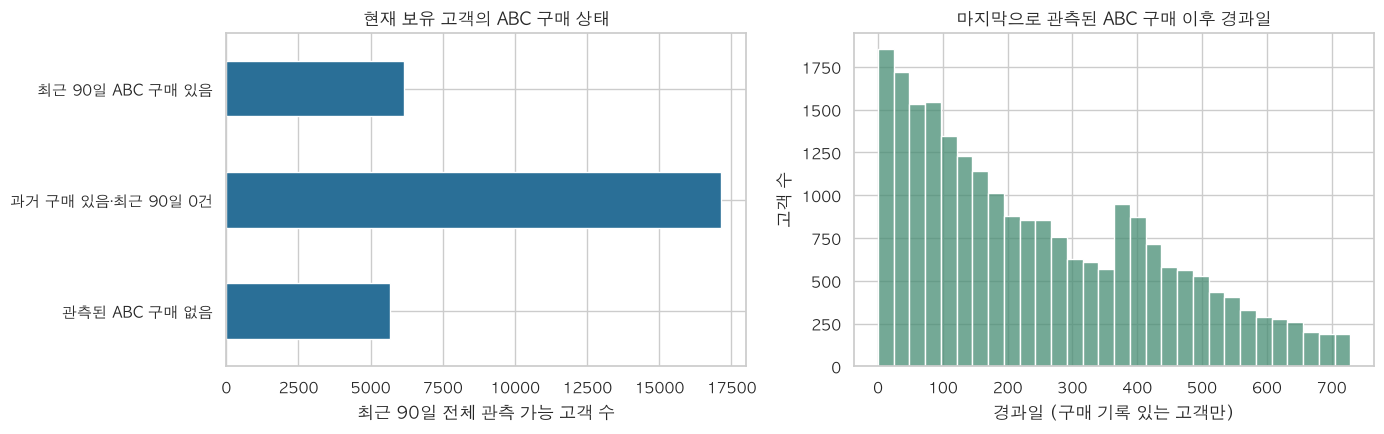

In [8]:
current_90 = current.loc[current["full_90_days"]].copy()
usage_groups = pd.Series(np.select(
    [current_90["abc_never_observed"], current_90["abc_zero_recent"]],
    ["관측된 ABC 구매 없음", "과거 구매 있음·최근 90일 0건"],
    default="최근 90일 ABC 구매 있음",
), index=current_90.index).value_counts().reindex(
    ["관측된 ABC 구매 없음", "과거 구매 있음·최근 90일 0건", "최근 90일 ABC 구매 있음"], fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
usage_groups.plot.barh(ax=axes[0], color="#2a6f97")
axes[0].set(title="현재 보유 고객의 ABC 구매 상태", xlabel="최근 90일 전체 관측 가능 고객 수", ylabel="")
sns.histplot(current_90["abc_recency_days"].dropna(), bins=30, ax=axes[1], color="#468c73")
axes[1].set(title="마지막으로 관측된 ABC 구매 이후 경과일", xlabel="경과일 (구매 기록 있는 고객만)", ylabel="고객 수")
fig.tight_layout()
plt.show()

## 7. ABC 해지 전 행동 비교 — 같은 기준일·같은 관측 기간

관측 종료일에 해지한 고객과 미해지 고객의 전체기간 구매를 비교하면, 해지 때문에 구매가 중단된 결과까지 섞일 수 있습니다.
여기서는 다음 순서로 **해지 전에 확인할 수 있었던 행동**을 비교합니다.

1. 이후 **60일**이 거래 관측 종료일까지 모두 포함되는 가장 최근 월말을 기준일로 선택합니다.
2. 기준일에 발급·미해지인 ABC 고객을 선택합니다. 직전·최근 90일을 공평하게 비교하기 위해 과거 **180일**을 모두 관측할 수 있는 고객으로 제한합니다.
3. 구매 특징은 기준일까지의 기록으로만 계산합니다.
4. 기준일 다음 날부터 60일 이내의 해지 여부로 그룹을 나눕니다. ‘60일 내 해지 기록 없음’은 그 이후에도 계속 보유한다는 뜻이 아닙니다.

신규 발급 고객은 이 비교에서 제외되므로 결과를 모든 고객에게 일반화하지 않습니다.
한 시점에서 탐색한 관계이며 여러 시점에서 재확인이 필요합니다. 해지일은 그룹 정답에만 사용하고 미래 구매는 입력하지 않습니다.

기준일: 2026-05-31 / 해지 확인: 2026-06-01 ~ 2026-07-30
직전 90일: 2025-12-03 ~ 2026-03-02
최근 90일: 2026-03-03 ~ 2026-05-31
기준일 ABC 보유 30,348명 → 180일 전체 관측 26,950명 (제외 3,398명)


outcome,60일 내 해지 기록 없음,60일 내 해지
고객 수,26418.00,532.00
최근 ABC 건수 평균,2.77,2.56
최근 ABC 건수 중앙값,0.00,0.00
최근 ABC 금액 평균,829.13,619.64
최근 ABC 금액 중앙값,0.00,0.00
최근 ABC 0건 비율(%),78.75,81.58
관측된 ABC 구매 없음(%),17.09,25.56
최근성 계산 가능 고객,21902.00,396.00
최근성 중앙값(일),207.00,184.50
최근-직전 ABC 건수 평균,-0.01,-0.02


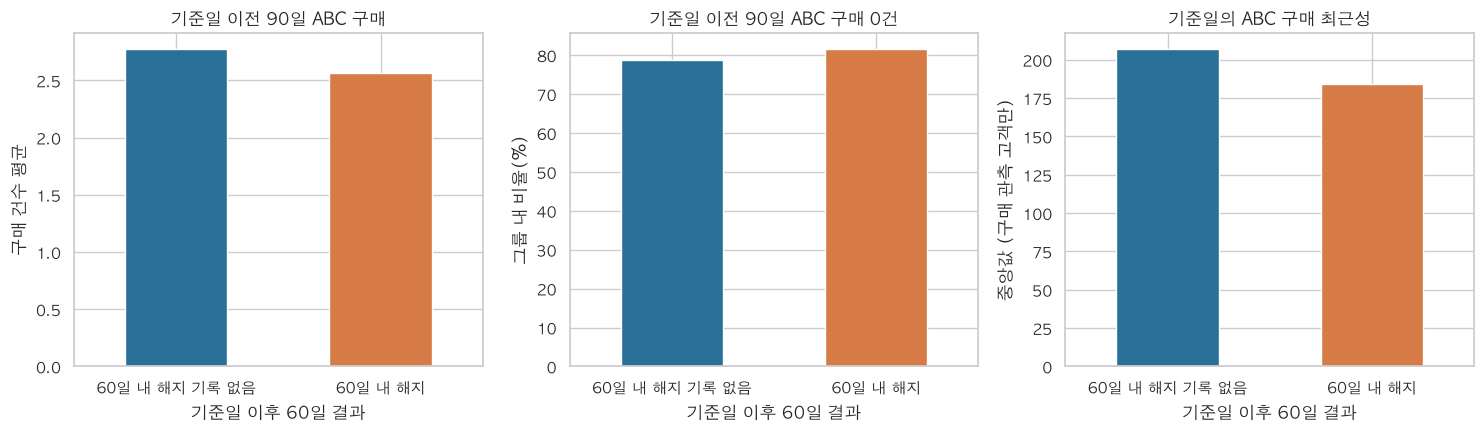

In [9]:
FOLLOWUP_DAYS = 60
cutoff = (observation_end - pd.Timedelta(days=FOLLOWUP_DAYS)) + pd.offsets.MonthEnd(0)
if cutoff + pd.Timedelta(days=FOLLOWUP_DAYS) > observation_end:
    cutoff -= pd.offsets.MonthEnd(1)
followup_end = cutoff + pd.Timedelta(days=FOLLOWUP_DAYS)
recent_start = cutoff - pd.Timedelta(days=WINDOW_DAYS - 1)
previous_start = cutoff - pd.Timedelta(days=2 * WINDOW_DAYS - 1)
assert previous_start >= observation_start
assert followup_end <= observation_end
at_cutoff = abc_behavior_as_of(cutoff)
comparison = at_cutoff.loc[at_cutoff["full_180_days"]].copy()
comparison["closed_next_60"] = closed.reindex(comparison.index).gt(cutoff) & closed.reindex(comparison.index).le(followup_end)
outcome_labels = ["60일 내 해지 기록 없음", "60일 내 해지"]
comparison["outcome"] = np.where(comparison["closed_next_60"], outcome_labels[1], outcome_labels[0])
assert opened.reindex(comparison.index).le(previous_start).all()
assert (closed.reindex(comparison.index).isna() | closed.reindex(comparison.index).gt(cutoff)).all()
print(f"기준일: {cutoff.date()} / 해지 확인: {(cutoff + pd.Timedelta(days=1)).date()} ~ {followup_end.date()}")
print(f"직전 90일: {previous_start.date()} ~ {(recent_start - pd.Timedelta(days=1)).date()}")
print(f"최근 90일: {recent_start.date()} ~ {cutoff.date()}")
print(f"기준일 ABC 보유 {len(at_cutoff):,}명 → 180일 전체 관측 {len(comparison):,}명 (제외 {len(at_cutoff) - len(comparison):,}명)")
comparison_summary = comparison.groupby("outcome").agg(
    customers=("closed_next_60", "size"),
    recent_count_mean=("abc_count_recent", "mean"), recent_count_median=("abc_count_recent", "median"),
    recent_amount_mean=("abc_amount_recent", "mean"), recent_amount_median=("abc_amount_recent", "median"),
    zero_recent_pct=("abc_zero_recent", lambda values: values.mean() * 100),
    no_history_pct=("abc_never_observed", lambda values: values.mean() * 100),
    recency_n=("abc_recency_days", "count"), recency_median=("abc_recency_days", "median"),
    count_change_mean=("abc_count_change", "mean"),
).reindex(outcome_labels)
comparison_names = {
    "customers": "고객 수", "recent_count_mean": "최근 ABC 건수 평균", "recent_count_median": "최근 ABC 건수 중앙값",
    "recent_amount_mean": "최근 ABC 금액 평균", "recent_amount_median": "최근 ABC 금액 중앙값",
    "zero_recent_pct": "최근 ABC 0건 비율(%)", "no_history_pct": "관측된 ABC 구매 없음(%)",
    "recency_n": "최근성 계산 가능 고객", "recency_median": "최근성 중앙값(일)", "count_change_mean": "최근-직전 ABC 건수 평균",
}
display(comparison_summary.rename(columns=comparison_names).round(2).T)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, column, title, ylabel in [
    (axes[0], "recent_count_mean", "기준일 이전 90일 ABC 구매", "구매 건수 평균"),
    (axes[1], "zero_recent_pct", "기준일 이전 90일 ABC 구매 0건", "그룹 내 비율(%)"),
    (axes[2], "recency_median", "기준일의 ABC 구매 최근성", "중앙값 (구매 관측 고객만)"),
]:
    comparison_summary[column].plot.bar(ax=ax, rot=0, color=["#2a6f97", "#d67b45"])
    ax.set(title=title, xlabel="기준일 이후 60일 결과", ylabel=ylabel)
fig.tight_layout()
plt.show()

## 8. 보조 분석: 같은 ABC 고객의 다른 결제수단 사용

**7절의 ABC 고객과 최근 90일을 그대로 사용**합니다. 전체 쇼핑몰 고객을 분모로 삼지 않습니다.
ABC 사용 비중은 동일 고객·기간의 ABC 구매 금액 ÷ 모든 결제수단 구매 금액입니다.
전체 구매가 0원이면 비중을 계산할 수 없으므로 `NaN`으로 유지합니다.

- ‘ABC 구매 중단·타 수단 구매’는 직전 90일 ABC 구매가 있었고 최근 90일 ABC 구매는 0건이면서 타 수단 구매가 있는 경우입니다.
- 이는 이 제휴몰 안의 **결제 이동 징후**이며, 특정 타 카드로의 완전한 전환이나 ABC 해지를 뜻하지 않습니다.
- 타 결제수단 구매만 있는 경우와 모든 수단 구매가 없는 경우를 구분합니다.
- 그룹별 해지 비율은 7절과 같은 이후 60일 결과이며, 인과관계나 검증된 예측 성능이 아닙니다.

,ABC 보유 고객 중 이용 고객,구매 건수,구매 금액,결제수단,동일 ABC 고객 구매 금액 비중(%)
Payment_Code,,,,,
1,4832,61374.0,11666200.75,Debit Card,12.78
2,3868,48615.0,11267497.85,Other Bank Credit Card,12.34
3,5711,74664.0,22233653.38,ABC Bank Credit Card,24.36
4,5685,74582.0,19104763.19,Cash/UPI,20.93
5,6147,82585.0,27005725.96,XYZ Wallet,29.59


한 고객이 여러 결제수단을 쓸 수 있으므로 수단별 고객 수는 더하지 않습니다.


,고객 수,60일 내 해지 고객,60일 내 해지 비율(%)
usage_segment,,,
최근 ABC 구매 있음,5711,98,1.72
ABC 구매 중단·타 수단 구매,2580,54,2.09
직전 ABC 0건·최근 타 수단만 구매,8954,195,2.18
최근 모든 수단 구매 없음,9705,185,1.91


outcome,60일 내 해지 기록 없음,60일 내 해지
고객 수,26418.00,532.00
비중 계산 가능 고객,16898.00,347.00
ABC 금액 합계,21904003.48,329649.90
모든 수단 금액 합계,89455723.11,1822118.02
고객별 ABC 금액 비중 중앙값(%),0.00,0.00
최근 타 수단만 구매한 고객 비율(%),42.72,46.80
그룹 금액 합계 기준 ABC 비중(%),24.49,18.09


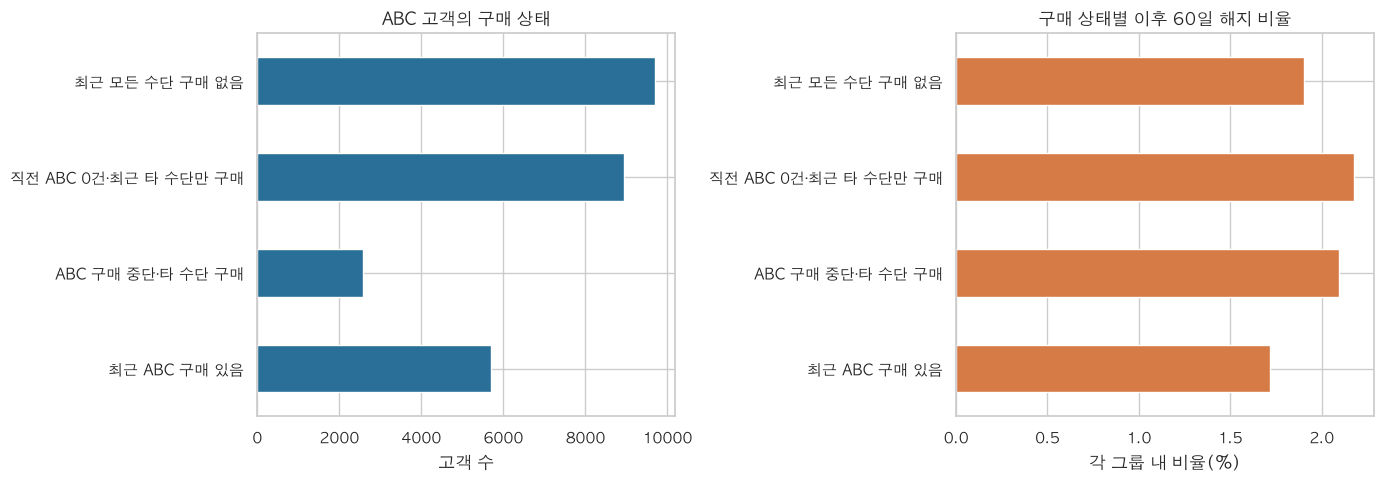

In [10]:
context_sales = owned_sales.loc[
    owned_sales["Customer_ID"].isin(comparison.index)
    & owned_sales["Transaction_Date"].between(recent_start, cutoff)
]
payment_context = context_sales.groupby("Payment_Code").agg(
    customers=("Customer_ID", "nunique"), count=("Number_of_Transactions", "sum"),
    amount=("Transaction_Amount", "sum"),
).reindex(payment_codes["Payment_Code"], fill_value=0).join(payment_codes.set_index("Payment_Code"))
payment_context["amount_share_pct"] = payment_context["amount"].div(payment_context["amount"].sum()).mul(100)
assert np.isclose(payment_context["amount"].sum(), comparison["all_amount_recent"].sum())
assert np.isclose(payment_context.loc[CARD_PAYMENT_CODE, "amount"], comparison["abc_amount_recent"].sum())
display(payment_context.rename(columns={
    "Payment_Method": "결제수단", "customers": "ABC 보유 고객 중 이용 고객", "count": "구매 건수",
    "amount": "구매 금액", "amount_share_pct": "동일 ABC 고객 구매 금액 비중(%)",
}).round(2))
print("한 고객이 여러 결제수단을 쓸 수 있으므로 수단별 고객 수는 더하지 않습니다.")

segment_order = ["최근 ABC 구매 있음", "ABC 구매 중단·타 수단 구매", "직전 ABC 0건·최근 타 수단만 구매", "최근 모든 수단 구매 없음"]
comparison["usage_segment"] = np.select(
    [comparison["abc_count_recent"].gt(0),
     comparison["abc_count_previous"].gt(0) & comparison["other_only_recent"],
     comparison["other_only_recent"]], segment_order[:3], default=segment_order[3],
)
segment_summary = comparison.groupby("usage_segment").agg(
    customers=("closed_next_60", "size"), closures=("closed_next_60", "sum"),
    close_pct=("closed_next_60", lambda values: values.mean() * 100),
).reindex(segment_order)
assert segment_summary["customers"].sum() == len(comparison)
assert segment_summary["closures"].sum() == comparison["closed_next_60"].sum()
display(segment_summary.rename(columns={"customers": "고객 수", "closures": "60일 내 해지 고객", "close_pct": "60일 내 해지 비율(%)"}).round(2))

share_summary = comparison.groupby("outcome").agg(
    customers=("closed_next_60", "size"), share_valid_customers=("abc_amount_share_pct", "count"),
    abc_amount=("abc_amount_recent", "sum"), all_amount=("all_amount_recent", "sum"),
    customer_share_median=("abc_amount_share_pct", "median"),
    other_only_pct=("other_only_recent", lambda values: values.mean() * 100),
).reindex(outcome_labels)
share_summary["amount_weighted_share_pct"] = share_summary["abc_amount"].div(share_summary["all_amount"].replace(0, np.nan)).mul(100)
display(share_summary.rename(columns={
    "customers": "고객 수", "share_valid_customers": "비중 계산 가능 고객", "abc_amount": "ABC 금액 합계",
    "all_amount": "모든 수단 금액 합계", "customer_share_median": "고객별 ABC 금액 비중 중앙값(%)",
    "other_only_pct": "최근 타 수단만 구매한 고객 비율(%)", "amount_weighted_share_pct": "그룹 금액 합계 기준 ABC 비중(%)",
}).round(2).T)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_summary["customers"].plot.barh(ax=axes[0], color="#2a6f97")
axes[0].set(title="ABC 고객의 구매 상태", xlabel="고객 수", ylabel="")
segment_summary["close_pct"].plot.barh(ax=axes[1], color="#d67b45")
axes[1].set(title="구매 상태별 이후 60일 해지 비율", xlabel="각 그룹 내 비율(%)", ylabel="")
fig.tight_layout()
plt.show()

## 9. ABC 카드 중심 결과 요약과 다음 단계

아래 결과는 실행한 원본에서 계산합니다. 전체 쇼핑몰 결제수단 순위 대신 ABC 보유·구매·해지 전 행동을 요약합니다.
해지 예측에서 사용할 수 있는 패턴인지는 여러 기준일과 별도의 미래 평가 기간에서 검증해야 합니다.

In [11]:
print(f"ABC EDA 대상 {len(abc_customers):,}명 / 종료일 미해지 {len(current):,}명")
print(f"ABC 구매 {len(abc_sales):,}행 / 구매 건수 합계 {abc_sales['Number_of_Transactions'].sum():,.0f}건")
print(f"보유 관측 기간 중 ABC 구매 0건: {abc_customers['abc_count'].eq(0).sum():,}명")
print(f"최근 90일 전체 관측 가능 미해지 고객 {len(current_90):,}명 중 ABC 구매 0건: {current_90['abc_zero_recent'].sum():,}명 ({current_90['abc_zero_recent'].mean() * 100:.2f}%)")
print(f"해지 전 비교 기준일 {cutoff.date()}: {len(comparison):,}명 중 이후 60일 해지 {comparison['closed_next_60'].sum():,}명 ({comparison['closed_next_60'].mean() * 100:.2f}%)")
for outcome in outcome_labels:
    row = comparison_summary.loc[outcome]
    print(f"  {outcome}: 최근 ABC 건수 평균 {row['recent_count_mean']:.2f}, 최근 ABC 0건 {row['zero_recent_pct']:.2f}%")
for segment in segment_order:
    row = segment_summary.loc[segment]
    print(f"  {segment}: {row['customers']:,.0f}명 / 이후 60일 해지 {row['close_pct']:.2f}%")
monthly_amount_change = monthly["abc_amount"].pct_change(fill_method=None).mul(100)
drop_month = monthly_amount_change.idxmin()
print(f"ABC 구매 금액의 전월 대비 최소 변화: {drop_month}, {monthly_amount_change.loc[drop_month]:+.2f}%")
print("급변 시점은 고객 구성·결제수단 이동·수집 기준을 추가 점검해야 하며, 이 차트로 원인을 확정하지 않습니다.")

ABC EDA 대상 36,334명 / 종료일 미해지 30,519명
ABC 구매 71,778행 / 구매 건수 합계 819,644건
보유 관측 기간 중 ABC 구매 0건: 9,715명
최근 90일 전체 관측 가능 미해지 고객 28,996명 중 ABC 구매 0건: 22,825명 (78.72%)
해지 전 비교 기준일 2026-05-31: 26,950명 중 이후 60일 해지 532명 (1.97%)
  60일 내 해지 기록 없음: 최근 ABC 건수 평균 2.77, 최근 ABC 0건 78.75%
  60일 내 해지: 최근 ABC 건수 평균 2.56, 최근 ABC 0건 81.58%
  최근 ABC 구매 있음: 5,711명 / 이후 60일 해지 1.72%
  ABC 구매 중단·타 수단 구매: 2,580명 / 이후 60일 해지 2.09%
  직전 ABC 0건·최근 타 수단만 구매: 8,954명 / 이후 60일 해지 2.18%
  최근 모든 수단 구매 없음: 9,705명 / 이후 60일 해지 1.91%
ABC 구매 금액의 전월 대비 최소 변화: 2025-08, -42.34%
급변 시점은 고객 구성·결제수단 이동·수집 기준을 추가 점검해야 하며, 이 차트로 원인을 확정하지 않습니다.


### 해석 및 후속 작업

1. **주 분석 대상은 ABC 카드 보유 고객입니다.** 거래 테이블에서 ABC 구매자만 추리면 미사용 보유 고객이 빠지므로 고객 테이블에서 대상을 먼저 정합니다.
2. ABC 구매 0건·감소, 마지막 구매 경과일, 구매 상품 범주 등을 행동 특징 후보로 사용합니다. 거래가 드문 고객이 많을 수 있어 중앙값뿐 아니라 평균·0건 비율·고객 수도 함께 봅니다.
3. 타 수단 사용은 동일 ABC 고객의 결제 이동을 설명하는 보조 특징입니다. 이를 모두 버리면 ABC만 덜 쓰는 상황과 쇼핑몰 구매 자체가 줄어든 상황을 구분하기 어렵습니다.
4. 7~8절의 단일 기준일 결과는 탐색용입니다. 신규 보유 고객을 제외한 영향과 계절성을 점검하고, 여러 기준일의 30일·60일 해지 정답으로 후속 검증합니다. 미래 기간이 부족한 정답은 `NaN`으로 유지합니다.
5. **해지 이후 거래 부재, 관측 종료일 상태, 미래 발급·해지일, 시점이 불명확한 고객 속성**을 과거 예측 입력에 넣지 않습니다. 해지일은 대상군 선정과 미래 정답 생성에만 사용합니다.
6. 모델용 자료 저장·학습·검증·평가 기간 분할은 다음 단계에서 수행합니다. 시간에 따른 관계를 점검하기 전에는 결과를 원인이나 검증된 위험 점수로 해석하지 않습니다.

기존 [스냅샷 코드](../../src/experiments/synchrony/data.py)와 [Synchrony 실험 안내](../../src/experiments/synchrony/README.md)를 참고합니다.